In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib


matplotlib.use("Agg")
os.makedirs("docs", exist_ok=True)

def load_data():
        df = pd.read_csv("../files/input/shipping-data.csv")
        return df
    
def create_visual_for_shipping_per_warehouse(df):
        df = df.copy()
        plt.figure()
        counts = df.Warehouse_block.value_counts()
        counts.plot.bar(
            title = "shipping per Warehouse",
            xlabel = "Warehouse block",
            ylabel = "Record Count",
            color = "tab:blue",
            fontsize = 8
        )



        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.savefig("docs/shipping_per_warehouse.png")



    #df = load_data()
    #create_visual_for_shipping_per_warehouse(df)


def create_visual_for_mode_shipment(df):
        df = df.copy()
        counts = df.Mode_of_Shipment.value_counts()
        counts.plot.pie(
            title = "Mode of shipment",
            wedgeprops =dict(width = 0.35),
            ylabel = "",
            colors = ["tab:blue", "tab:orange", "tab:green"]
        )

        plt.savefig("docs/mode_of_shipment.png")



        
    #df = load_data()
    #create_visual_for_mode_shipment(df)



def create_visual_for_average_customer_rating(df):
        df = df.copy()
        plt.figure()
        df = (
            df[["Mode_of_Shipment","Customer_rating"]]
            .groupby("Mode_of_Shipment")
            .describe()
        ) 
        df.columns = df.columns.droplevel()
        df = df[["mean", "min", "max"]]
        plt.barh(
            y =df.index.values,
            width = df["max"].values - 1,
            left = df["min"].values,
            height= 0.9,
            color = "lightgray",
            alpha = 0.8
            )
        colors =["tab:green" if value >= 3.0 else "tab:orange" for value in df["mean"].values]
        plt.barh(
            y =df.index.values,
            width = df["mean"].values - 1,
            left = df["min"].values,
            height= 0.5,
            color = colors,
            alpha = 1.0
            )
        plt.title("Average Customer Rating")
        plt.gca().spines["left"].set_color("gray")
        plt.gca().spines["bottom"].set_color("gray")
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.savefig("docs/average_customer_rating.png")
        
        

        
    #df = load_data()
    #create_visual_for_average_customer_rating(df)



def create_visual_for_weight_distribution(df):
        df = df.copy()
        df.Weight_in_gms.plot.hist(
            title = "Shipped Weight Distribution",
            color = "tab:orange",
            edgecolor = "white"
        )
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.savefig("docs/weight_distribution.png")
        plt.tight_layout()
        plt.show()


    #df = load_data()
    #create_visual_for_weight_distribution(df)







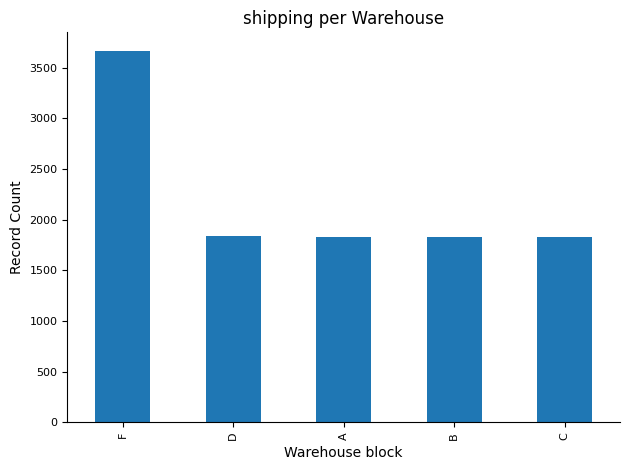

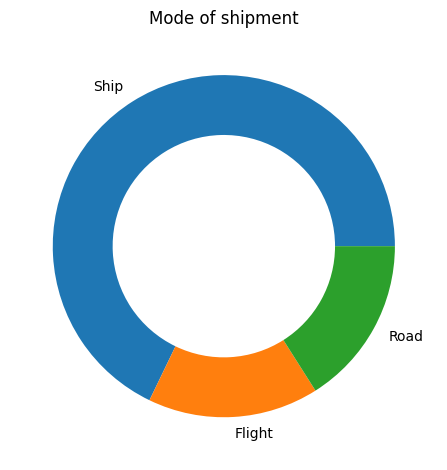

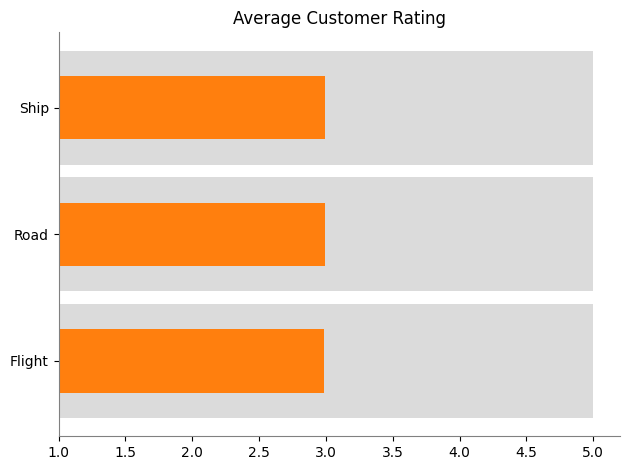

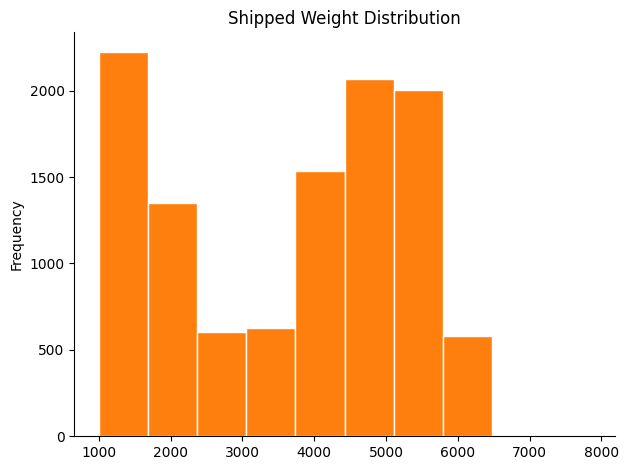

In [10]:
df = load_data()
create_visual_for_shipping_per_warehouse(df)
create_visual_for_mode_shipment(df)
create_visual_for_average_customer_rating(df)
create_visual_for_weight_distribution(df)

In [12]:
%%writefile index.html

<!DOCTYPE html>
<html>
    <body>
        <h1>Shipping Dashboard Example</h1>
        <div style="width:45%;float:left">
            <img src="docs/shipping_per_warehouse.png" alt="Fig 1">
            <img src="docs/mode_of_shipment.png" alt="Fig 2">
        </div>
        <div style="width:45%;float:left">
            <img src="docs/average_customer_rating.png" alt="Fig 3">
            <img src="docs/weight_distribution.png" alt="Fig 4">
        </div>
    </body>
</html>


Overwriting index.html
